# 02_Bayesian_Cruise_Optimization.ipynb

## Uçak Performans Mühendisliği ve Uçuş Fiziği Portföyü

Bu defter, veri biliminde kullanılan optimizasyon tekniklerinin uçak performans mühendisliğine nasıl uygulanabileceğini göstermektedir. Özellikle, bir turboprop uçağın optimum seyir işletme koşullarını belirlemek için Bayesçi Optimizasyon kullanılacaktır. Amaç, yakıt tüketimini en aza indirirken uçuş menzilini en üst düzeye çıkarmaktır.

## Bölüm 1 - Giriş

### Seyir Optimizasyonu Neden Önemlidir?

Seyir optimizasyonu, havacılıkta yakıt verimliliğini ve operasyonel maliyetleri doğrudan etkilediği için kritik bir öneme sahiptir. Uçaklar, seyir aşamasında uçuş süresinin önemli bir bölümünü geçirirler ve bu aşamadaki küçük iyileştirmeler bile uzun vadede büyük yakıt tasarrufları sağlayabilir. Optimum seyir yüksekliği ve hızı seçimi, hem menzili maksimize etmek hem de yakıt tüketimini minimize etmek için hayati öneme sahiptir.

### Uçak Performansı ve Yakıt Tüketimi Arasındaki İlişki

Uçak performansı ile yakıt tüketimi arasındaki ilişki karmaşıktır ve birçok aerodinamik, motor ve operasyonel faktöre bağlıdır. Örneğin, daha yüksek hızlar genellikle daha fazla sürüklenmeye ve dolayısıyla daha yüksek yakıt akışına yol açarken, çok düşük hızlar da verimsiz olabilir. Benzer şekilde, irtifa arttıkça hava yoğunluğu azalır, bu da sürüklenmeyi azaltır ancak motor performansı ve pervane verimliliği üzerinde etkileri olabilir. Bu dengeyi bulmak, optimum performansı elde etmek için gereklidir.

### Optimizasyonun Havacılık Mühendisliğindeki Önemi

Optimizasyon teknikleri, havacılık mühendisliğinde geniş bir uygulama yelpazesine sahiptir. Uçak tasarımından (kanat profili optimizasyonu, yapısal hafifletme) operasyonel planlamaya (rota optimizasyonu, yük optimizasyonu) kadar birçok alanda verimlilik artışı sağlarlar. Özellikle uçuş performansında, en uygun seyir parametrelerini belirlemek, hem ekonomik hem de çevresel faydalar sunarak havacılık endüstrisinin sürdürülebilirliğine katkıda bulunur.

### Değerlendirmelerin Maliyetli Olduğu Durumlarda Bayesçi Optimizasyon Neden Yararlıdır?

Bayesçi Optimizasyon, hedef fonksiyon değerlendirmelerinin pahalı olduğu veya zaman alıcı olduğu durumlarda özellikle etkili bir optimizasyon tekniğidir. Uçak performansı modellemesinde veya gerçek uçuş testlerinde, her bir parametre kombinasyonunun (örneğin, belirli bir irtifa ve hız) değerlendirilmesi maliyetli olabilir. Bayesçi Optimizasyon, bir vekil model (genellikle bir Gauss Süreci) kullanarak bilinmeyen hedef fonksiyon hakkında bilgi edinir ve bir sonraki değerlendirilecek noktayı seçmek için bir edinme fonksiyonu kullanır. Bu sayede, optimuma ulaşmak için gereken değerlendirme sayısını önemli ölçüde azaltır, bu da onu havacılık gibi karmaşık ve maliyetli sistemler için ideal hale getirir.

## Bölüm 2 - Arka Plan Teorisi

### Menzil

Menzil (Range), bir uçağın belirli bir yakıt miktarı ile katedebileceği maksimum mesafedir. Yakıt verimliliği ve menzil, uçak performansının temel metrikleridir. Menzil, uçağın taşıdığı yakıt miktarı, özgül yakıt tüketimi, hız ve irtifa gibi birçok faktöre bağlıdır.

### Yakıt Verimliliği

Yakıt verimliliği (Fuel Efficiency), uçağın belirli bir mesafeyi katetmek için ne kadar yakıt tükettiğini ifade eder. Genellikle birim mesafe başına yakıt tüketimi veya kat edilen mesafe başına yakıt tüketiminin tersi olarak ifade edilir. Yüksek yakıt verimliliği, daha düşük işletme maliyetleri ve daha az çevresel etki anlamına gelir.

### Özgül Menzil

Özgül menzil (Specific Range), birim yakıt tüketimi başına kat edilen mesafedir. Genellikle `nm/kg` veya `km/kg` birimleriyle ifade edilir. Özgül menzili maksimize etmek, aynı zamanda toplam menzili maksimize etmek anlamına gelir ve bu, seyir optimizasyonunun ana hedeflerinden biridir.

Özgül Menzil Formülü:

$$ \text{Specific Range} = \frac{\text{True Airspeed (TAS)}}{\text{Fuel Flow (FF)}} \quad [\text{km/kg veya nm/kg}] $$

### Objektif Fonksiyon (Objective Function)

Bu optimizasyon probleminde, hedef fonksiyonumuz özgül menzili maksimize etmektir. Bayesçi Optimizasyon genellikle minimizasyon problemleri için tasarlandığından, objektif fonksiyonumuzu negatif özgül menzil olarak tanımlayacağız:

$$ \text{Loss} = -\text{Specific Range} $$

Bu sayede, `Loss` fonksiyonunu minimize ederek aslında `Specific Range`'i maksimize etmiş olacağız.

### Tasarım Değişkenleri (Design Variables)

Optimizasyon problemimizin tasarım değişkenleri şunlardır:

*   **Seyir İrtifası (Cruise Altitude):** `h` (feet cinsinden)
*   **Seyir Gerçek Hava Hızı (Cruise True Airspeed):** `V_{TAS}` (knot cinsinden)

### Kısıtlamalar (Constraints)

Optimizasyon sürecinde, tasarım değişkenlerimiz belirli sınırlar içinde kalmalıdır. Bu sınırlar, uçağın operasyonel limitlerini ve pratik kısıtlamalarını temsil eder:

*   **Minimum İrtifa:** $ h_{\text{min}} $
*   **Maksimum İrtifa:** $ h_{\text{max}} $
*   **Minimum Hız:** $ V_{\text{TAS,min}} $
*   **Maksimum Hız:** $ V_{\text{TAS,max}} $

## Bölüm 3 - Sentetik Uçak Performans Modeli

Bu bölümde, turboprop bir uçağın performansını simüle etmek için basitleştirilmiş ancak mühendislik düzeyinde gerçekçi bir model oluşturulacaktır. Model, yakıt akışı ve sürüklenme özelliklerini içererek farklı irtifa ve hız koşullarında uçağın nasıl performans gösterdiğini tahmin edecektir. Bu sentetik model, gerçek dünya verileri yerine kullanılacak ve Bayesçi Optimizasyon için test ortamı sağlayacaktır.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d

# Configure matplotlib for publication-quality plots
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18,
    'lines.linewidth': 2,
    'grid.linestyle': '--',
    'grid.alpha': 0.7
})
sns.set_style("whitegrid")

In [ ]:
# Aircraft parameters (TBM-like turboprop)
WEIGHT = 6000 # Aircraft weight in lbs (example: TBM 960 MTOW ~7394 lbs)
S = 180       # Wing area in sq ft (example: TBM 960 ~193.7 sq ft)
AR = 10       # Aspect ratio (example: TBM 960 ~10.4)
e = 0.85      # Oswald efficiency factor (typical for general aviation)
CD0 = 0.025   # Zero-lift drag coefficient (typical for turboprops)

# Standard Atmosphere Model (simplified for cruise altitudes)
def get_density_ratio(altitude_ft):
    # Simplified standard atmosphere model for density ratio (sigma)
    # This is a rough approximation, more accurate models would use tables or more complex equations
    # For 0-36089 ft, temperature decreases linearly
    # Pressure ratio = (1 - 0.0000068755 * h_ft / 518.67)**5.256
    # Density ratio = Pressure ratio / (Temp ratio)

    # Using a common approximation for density ratio up to ~40,000 ft
    # At sea level: density_ratio = 1.0
    # At 20,000 ft: density_ratio ~ 0.517
    # At 30,000 ft: density_ratio ~ 0.374
    # At 35,000 ft: density_ratio ~ 0.309

    # Source for values: NASA Glenn Research Center, International Standard Atmosphere
    # Using interpolation for simplicity and realism for this synthetic model
    altitudes = np.array([0, 5000, 10000, 15000, 20000, 25000, 30000, 35000])
    density_ratios = np.array([1.0, 0.8617, 0.7385, 0.6292, 0.5326, 0.4479, 0.3741, 0.3090])

    if altitude_ft < altitudes[0]:
        return density_ratios[0]
    elif altitude_ft > altitudes[-1]:
        # Extrapolate or cap at highest given value, capping here.
        return density_ratios[-1]

    interp_func = interp1d(altitudes, density_ratios, kind='linear')
    return interp_func(altitude_ft)


# Fuel Flow Model (simplified for a turboprop)
def calculate_fuel_flow(altitude_ft, tas_knots, weight_lbs=WEIGHT):
    # A simplified fuel flow model that combines engine specific fuel consumption (SFC)
    # and engine power output. Engine power depends on thrust and speed.
    # Thrust required depends on drag.

    # Constants
    g = 32.174 # ft/s^2
    rho_sl = 0.0023769 # slugs/ft^3 (sea level standard density)
    k_to_fps = 1.68781 # knots to ft/s
    lb_to_kg = 0.453592 # lbs to kg

    # Convert TAS from knots to ft/s
    tas_fps = tas_knots * k_to_fps

    # Get density ratio at altitude
    sigma = get_density_ratio(altitude_ft)
    rho = rho_sl * sigma # Density at altitude

    # Calculate lift coefficient (CL)
    CL = (2 * weight_lbs) / (rho * S * tas_fps**2)

    # Calculate drag coefficient (CD)
    CD = CD0 + (CL**2) / (np.pi * AR * e)

    # Calculate total drag (D)
    D = 0.5 * rho * S * tas_fps**2 * CD

    # Thrust required (T) = Drag (D) in steady level flight
    Thrust_req_lbs = D

    # Simplified SFC model (varies with altitude and power/thrust)
    # For turboprops, SFC tends to decrease slightly with altitude up to an optimum,
    # then increase. Also, it increases with higher power settings.
    # Let's use a base SFC and adjust it.
    base_sfc_lb_hr_hp = 0.45 # typical SFC for turboprops (lb/hr/hp)

    # Engine efficiency adjustment based on altitude (simulated effect)
    # Higher altitude generally means less power available, but also less drag for same TAS (IAS decreases)
    # Let's assume SFC improves slightly with altitude up to an optimal point
    sfc_altitude_factor = 1 - 0.000005 * altitude_ft # small improvement with altitude
    if altitude_ft > 25000: # Beyond certain altitude, SFC might degrade due to turbocharger limits, etc.
        sfc_altitude_factor = 1 - 0.000005 * 25000 + 0.00000005 * (altitude_ft - 25000)**2 # Degradation model

    sfc = base_sfc_lb_hr_hp * sfc_altitude_factor

    # Power required (HP) = (Thrust * TAS) / 550 (if thrust in lbs, TAS in ft/s)
    Power_req_hp = (Thrust_req_lbs * tas_fps) / 550.0

    # Fuel Flow (lbs/hr) = SFC * Power_req_hp
    fuel_flow_lbs_hr = sfc * Power_req_hp

    # Convert fuel flow to kg/hr for specific range calculation
    fuel_flow_kg_hr = fuel_flow_lbs_hr * lb_to_kg

    return fuel_flow_kg_hr

# Specific Range Calculation
def calculate_specific_range(altitude_ft, tas_knots, weight_lbs=WEIGHT):
    fuel_flow_kg_hr = calculate_fuel_flow(altitude_ft, tas_knots, weight_lbs)

    # Specific range in km/kg (TAS in km/hr, Fuel Flow in kg/hr)
    # 1 knot = 1.852 km/hr
    tas_km_hr = tas_knots * 1.852

    if fuel_flow_kg_hr <= 0: # Avoid division by zero or negative fuel flow
        return 0.0

    specific_range_km_kg = tas_km_hr / fuel_flow_kg_hr

    return specific_range_km_kg


# Define the range of design variables for data generation
altitudes = np.linspace(5000, 35000, 15)  # ft
tas_speeds = np.linspace(150, 300, 20)  # knots

# Create a list to store performance data
performance_data = []

# Generate performance dataset
for alt in altitudes:
    for speed in tas_speeds:
        ff = calculate_fuel_flow(alt, speed)
        sr = calculate_specific_range(alt, speed)

        # Assuming a mission time for estimating total fuel consumption (e.g., 2-hour mission)
        mission_time_hr = 2.0
        estimated_mission_fuel = ff * mission_time_hr

        performance_data.append({
            'altitude_ft': alt,
            'tas_knots': speed,
            'fuel_flow_kg_hr': ff,
            'specific_range_km_kg': sr,
            'estimated_mission_fuel_kg': estimated_mission_fuel
        })

# Create a pandas DataFrame
df_performance = pd.DataFrame(performance_data)

#### Oluşturulan Performans Veri Kümesinin İlk Beş Satırı

In [ ]:
# Display sample rows of the generated performance data
display(df_performance.head())

,altitude_ft,tas_knots,fuel_flow_kg_hr,specific_range_km_kg,estimated_mission_fuel_kg
0,5000.0,150.000000,37.511845,7.405661,75.023690
1,5000.0,157.894737,41.490516,7.047901,82.981032
2,5000.0,165.789474,45.992369,6.675936,91.984737
3,5000.0,173.684211,51.034285,6.302884,102.068571
4,5000.0,181.578947,56.634329,5.937816,113.268659


In [ ]:
df_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   altitude_ft                300 non-null    float64
 1   tas_knots                  300 non-null    float64
 2   fuel_flow_kg_hr            300 non-null    float64
 3   specific_range_km_kg       300 non-null    float64
 4   estimated_mission_fuel_kg  300 non-null    float64
dtypes: float64(5)
memory usage: 11.8 KB


In [ ]:
df_performance.describe()

,altitude_ft,tas_knots,fuel_flow_kg_hr,specific_range_km_kg,estimated_mission_fuel_kg
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,20000.000000,225.000000,115.572643,5.073551,231.145286
std,9273.670016,45.599336,90.352252,2.246849,180.704504
min,5000.000000,150.000000,30.660430,1.000060,61.320860
25%,11428.571429,187.500000,53.653217,3.276159,107.306434
50%,20000.000000,225.000000,89.505436,5.069372,179.010873
75%,28571.428571,262.500000,141.984768,6.968806,283.969535
max,35000.000000,300.000000,555.566631,9.154967,1111.133261


## Bölüm 4 - Keşifsel Veri Analizi (Exploratory Data Analysis)

Bu bölümde, oluşturulan sentetik uçak performans verilerini görselleştirerek temel eğilimleri ve ilişkileri keşfedeceğiz. Bu analiz, uçağın farklı seyir koşullarındaki davranışını anlamamıza ve optimizasyon problemine daha iyi bir bağlam sağlamamıza yardımcı olacaktır. Yakıt akışı ve özgül menzilin hız ve irtifa ile nasıl değiştiğini inceleyeceğiz.

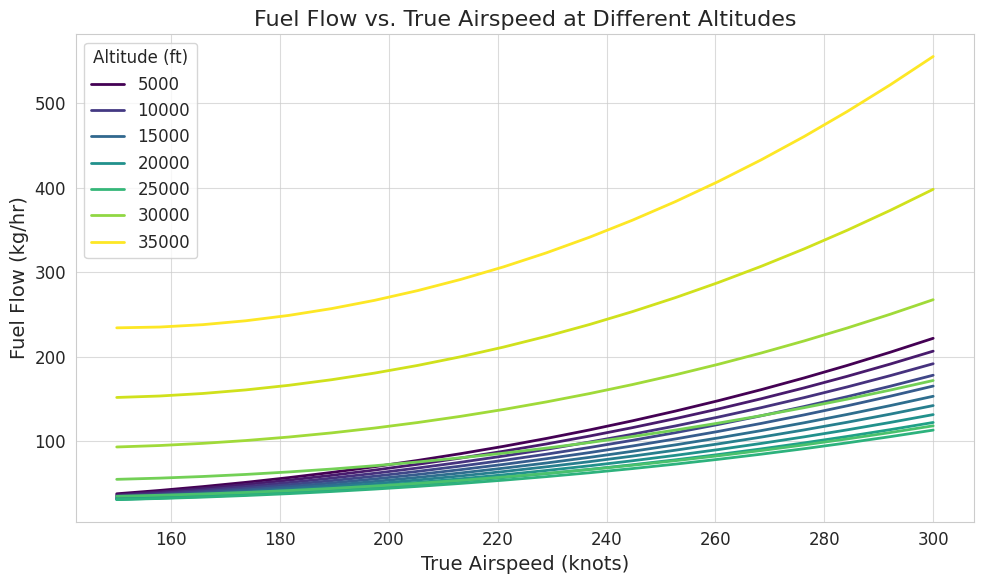

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Fuel Flow vs. Speed ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_performance, x='tas_knots', y='fuel_flow_kg_hr', hue='altitude_ft', palette='viridis')
plt.title('Fuel Flow vs. True Airspeed at Different Altitudes')
plt.xlabel('True Airspeed (knots)')
plt.ylabel('Fuel Flow (kg/hr)')
plt.legend(title='Altitude (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Yakıt Akışı - Hız İlişkisi

Yukarıdaki grafik, farklı irtifalarda gerçek hava hızı (`True Airspeed`) arttıkça yakıt akışının (`Fuel Flow`) nasıl değiştiğini göstermektedir. Görüldüğü üzere, tüm irtifalarda hız arttıkça yakıt akışı parabolik bir şekilde artmaktadır. Bu durum, daha yüksek hızlarda uçağın hava direncini yenmek için daha fazla itki üretmesi gerektiği ve bu da daha fazla yakıt tüketimi anlamına geldiği beklenen bir durumdur. Daha yüksek irtifalarda ise aynı hız için yakıt akışının genellikle daha düşük olduğu gözlemlenmektedir. Bunun nedeni, daha yüksek irtifalarda hava yoğunluğunun azalmasıyla sürüklenmenin azalması ve dolayısıyla aynı itkiyi üretmek için daha az yakıt gerekmesidir. Ancak, belirli bir irtifanın üzerinde motor verimliliğindeki düşüşler bu eğilimi değiştirebilir.

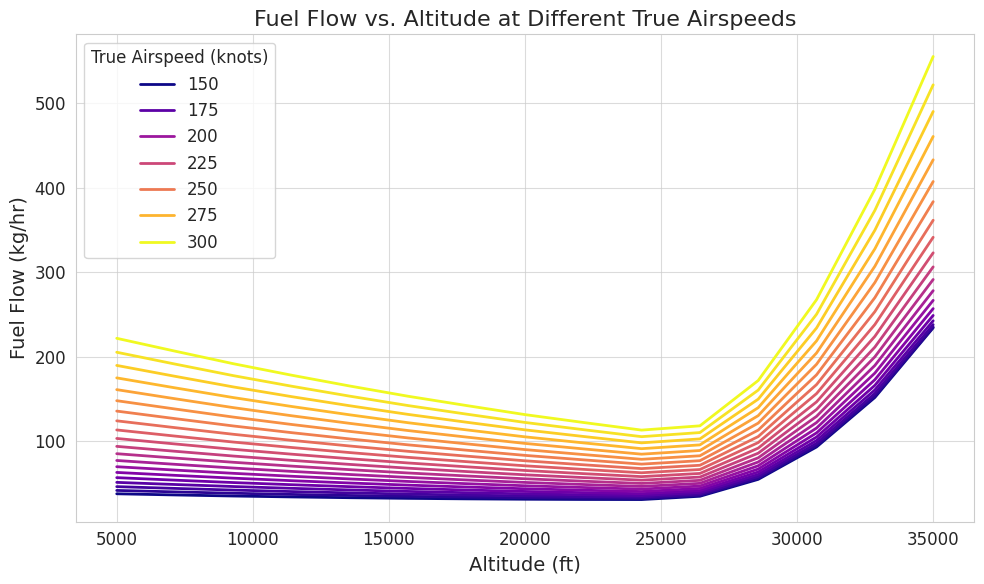

In [ ]:
# --- Fuel Flow vs. Altitude ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_performance, x='altitude_ft', y='fuel_flow_kg_hr', hue='tas_knots', palette='plasma')
plt.title('Fuel Flow vs. Altitude at Different True Airspeeds')
plt.xlabel('Altitude (ft)')
plt.ylabel('Fuel Flow (kg/hr)')
plt.legend(title='True Airspeed (knots)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Yakıt Akışı - İrtifa İlişkisi

Bu grafik, farklı gerçek hava hızlarında irtifa arttıkça yakıt akışının nasıl değiştiğini ortaya koymaktadır. Genel olarak, belirli bir hız için irtifa arttıkça yakıt akışında bir azalma eğilimi görülmektedir. Bu, daha yüksek irtifalarda azalan hava yoğunluğu nedeniyle daha az sürüklenme yaşanması ve dolayısıyla uçağı aynı hızda tutmak için daha az itki gerekliliği ile açıklanabilir. Ancak, çok yüksek irtifalarda motor performansının düşmesi ve itki üretimi için daha fazla çaba sarf edilmesi gerektiğinden yakıt akışı tekrar artmaya başlayabilir. Grafik, her hız için optimum bir seyir irtifası olabileceğini düşündürmektedir.

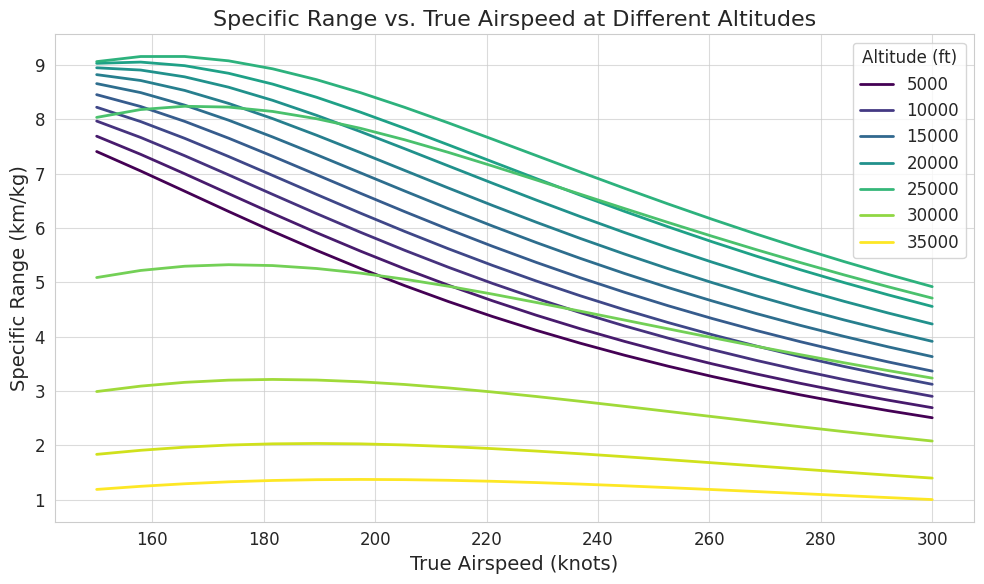

In [ ]:
# --- Specific Range vs. Speed ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_performance, x='tas_knots', y='specific_range_km_kg', hue='altitude_ft', palette='viridis')
plt.title('Specific Range vs. True Airspeed at Different Altitudes')
plt.xlabel('True Airspeed (knots)')
plt.ylabel('Specific Range (km/kg)')
plt.legend(title='Altitude (ft)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Özgül Menzil - Hız İlişkisi

Bu grafik, farklı irtifalarda hız ile özgül menzil (`Specific Range`) arasındaki ilişkiyi göstermektedir. Her irtifa için özgül menzilin belirli bir hızda zirve yaptığını ve bu optimum hızın altında veya üstünde azaldığını görmekteyiz. Bu, uçuş performansı teorisinde beklenen bir durumdur: çok yavaş hızlarda artan hücum açısı nedeniyle indüklenmiş sürükleme artarken, çok yüksek hızlarda parazit sürükleme önemli hale gelir. Optimum hız, bu sürüklenme bileşenlerinin dengelendiği noktadır. Ayrıca, genellikle daha yüksek irtifalarda daha iyi özgül menzil değerlerine ulaşılabilmektedir, çünkü daha düşük hava yoğunluğu sürüklenmeyi azaltarak daha verimli bir uçuşa olanak tanır. Optimum hız, irtifa ile birlikte biraz kayma eğilimi gösterebilir.

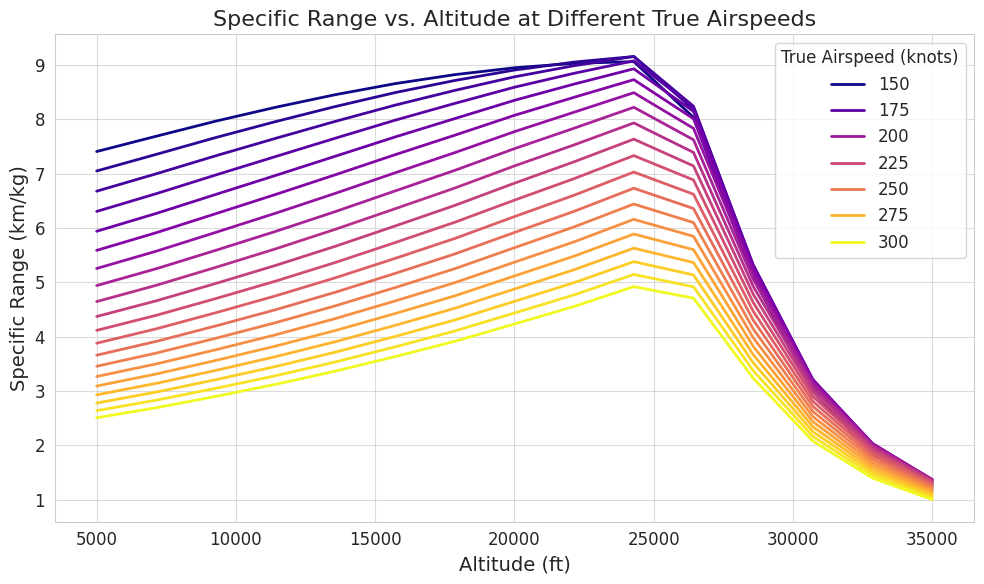

In [ ]:
# --- Specific Range vs. Altitude ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_performance, x='altitude_ft', y='specific_range_km_kg', hue='tas_knots', palette='plasma')
plt.title('Specific Range vs. Altitude at Different True Airspeeds')
plt.xlabel('Altitude (ft)')
plt.ylabel('Specific Range (km/kg)')
plt.legend(title='True Airspeed (knots)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Özgül Menzil - İrtifa İlişkisi

Son grafik, farklı hızlarda irtifa ile özgül menzil arasındaki bağıntıyı incelemektedir. Grafikte, her hız çizgisi için belirli bir irtifa aralığında özgül menzilin genellikle arttığı, ardından zirveye ulaştığı ve daha sonra azaldığı görülmektedir. Bu eğilim, irtifa arttıkça hava yoğunluğunun azalmasıyla sürüklenmenin azalmasından kaynaklanır, bu da belirli bir hızda daha az itki ve yakıt tüketimi anlamına gelir. Ancak, çok yüksek irtifalarda motor performansının düşmesi ve pervanenin verimliliğinin azalması gibi faktörler, özgül menzilde bir düşüşe neden olabilir. Bu nedenle, her hız için en uygun bir seyir irtifası bulunmaktadır. Bu tür grafikler, uçuş planlamacıları için kritik önem taşır ve en verimli uçuş profillerini belirlemeye yardımcı olur.

## Bölüm 5 - Optimizasyon Problemi Tanımı

Bu bölümde, Bayesçi Optimizasyonun uygulanacağı optimizasyon problemini resmi olarak tanımlayacağız. Bir turboprop uçağın seyir operasyonları için optimum koşulları bulmak amacıyla, belirli tasarım değişkenleri, bir amaç fonksiyonu ve kısıtlamalar belirleyeceğiz. Amacımız, yakıt tüketimini minimize ederken menzili maksimize etmektir, bu da özgül menzili maksimize etmekle eşdeğerdir.

### Karar Değişkenleri (Decision Variables)

Optimizasyon problemimizde, uçağın performansı üzerinde kontrol edebileceğimiz iki ana parametre bulunmaktadır:

*   **Altitude (İrtifa):** Seyir yüksekliği (feet cinsinden).
*   **Cruise Speed (Seyir Hızı):** Gerçek hava hızı (knots cinsinden).

Bu değişkenler, uçuş sırasında ayarlanabilir ve uçağın yakıt verimliliğini ve menzilini doğrudan etkiler.

### Amaç (Objective)

Temel amacımız, uçuş menzilini maksimize etmektir. Bu, aynı zamanda **özgül menzili (specific range)** maksimize etmekle eşdeğerdir. Özgül menzil, birim yakıt başına kat edilen mesafeyi ifade eder ve uçağın yakıt verimliliğinin doğrudan bir ölçüsüdür.

### Eşdeğer Minimizasyon Formu (Equivalent Minimization Form)

Bayesçi Optimizasyon algoritmaları genellikle bir hedef fonksiyonu minimize etmek üzere tasarlanmıştır. Bu nedenle, özgül menzili maksimize etme amacımızı bir minimizasyon problemine dönüştürmek için, amaç fonksiyonumuzu **negatif özgül menzil** olarak tanımlayacağız:

$$ \text{Loss} = -\text{Specific Range} $$

Böylece, bu `Loss` fonksiyonunu minimize ederek, gerçekte `Specific Range`'i maksimize etmiş olacağız.

### Kısıtlamalar (Constraints)

Karar değişkenlerimiz, uçağın operasyonel limitleri ve fiziksel kısıtlamaları dahilinde kalmalıdır. Bu sınırlar, optimizasyon sürecimizin geçerli bir çözüm bulmasını sağlar:

*   **Minimum İrtifa ($h_{\text{min}}$):** 5,000 ft (Genellikle yoğun hava trafiğinden kaçınmak ve motor performansını dengelemek için minimum seyir irtifası)
*   **Maksimum İrtifa ($h_{\text{max}}$):** 35,000 ft (TBM benzeri turboprop uçakların tipik maksimum operasyonel irtifası)
*   **Minimum Hız ($V_{\text{TAS,min}}$):** 150 knot (Minimum güvenli seyir hızı veya ekonomik seyir hızının alt sınırı)
*   **Maksimum Hız ($V_{\text{TAS,max}}$):** 300 knot (Uçağın maksimum seyir hızı veya yapısal limitler dahilinde maksimum hız)

Bu kısıtlamalar, optimizasyon algoritmasının arama uzayını tanımlar.

### Tasarım Uzayının Görselleştirilmesi

Optimizasyonun gerçekleşeceği tasarım uzayını görselleştirmek, değişkenlerin aralıklarını ve potansiyel çözüm alanını anlamak için faydalıdır. Aşağıdaki grafikler, irtifa ve hızın farklı kombinasyonlarında özgül menzilin nasıl dağıldığını gösterecektir.

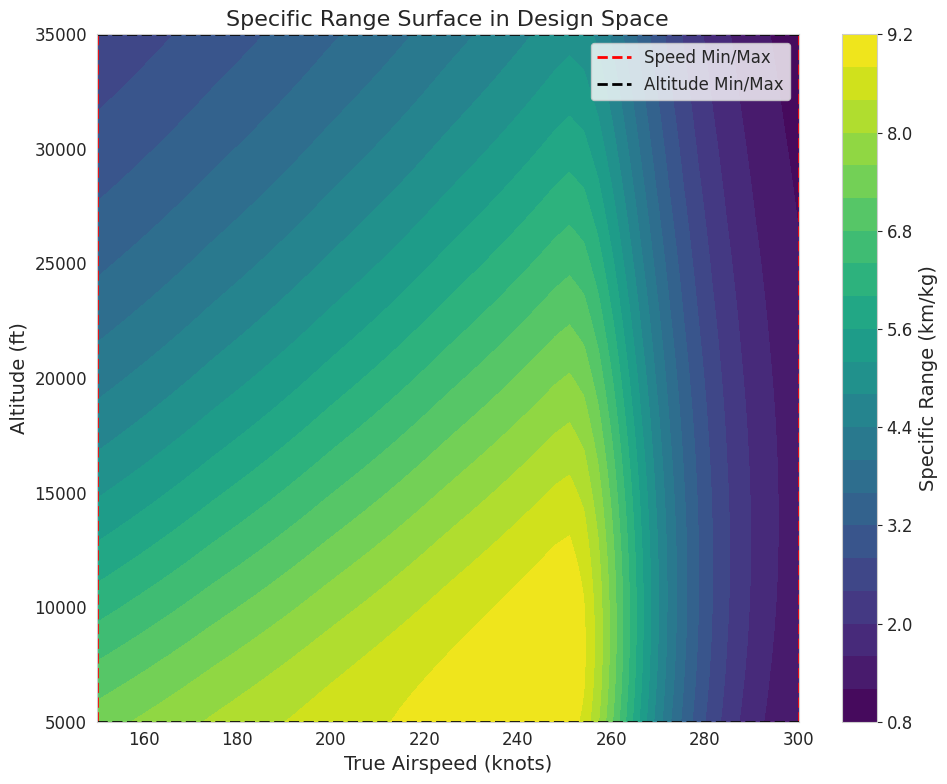

Optimization Design Space:
  Altitude: 5000 ft to 35000 ft
  True Airspeed: 150 knots to 300 knots


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the bounds for the design variables
altitude_min = 5000   # ft
altitude_max = 35000  # ft
speed_min = 150       # knots
speed_max = 300       # knots

# Create a meshgrid for visualization
alt_range = np.linspace(altitude_min, altitude_max, 50)
speed_range = np.linspace(speed_min, speed_max, 50)
ALT, SPEED = np.meshgrid(alt_range, speed_range)

# Calculate specific range for each point in the meshgrid
SR_values = np.array([[calculate_specific_range(a, s) for s in speed_range] for a in alt_range])

# Create a contour plot of Specific Range over the design space
plt.figure(figsize=(10, 8))
contour = plt.contourf(SPEED, ALT, SR_values, levels=20, cmap='viridis')
plt.colorbar(contour, label='Specific Range (km/kg)')
plt.title('Specific Range Surface in Design Space')
plt.xlabel('True Airspeed (knots)')
plt.ylabel('Altitude (ft)')

# Mark the search boundaries
plt.axvline(x=speed_min, color='r', linestyle='--', label='Speed Min/Max')
plt.axvline(x=speed_max, color='r', linestyle='--')
plt.axhline(y=altitude_min, color='k', linestyle='--', label='Altitude Min/Max')
plt.axhline(y=altitude_max, color='k', linestyle='--')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Optimization Design Space:")
print(f"  Altitude: {altitude_min} ft to {altitude_max} ft")
print(f"  True Airspeed: {speed_min} knots to {speed_max} knots")

## Bölüm 6 - Bayesçi Optimizasyon

Bayesçi Optimizasyon (Bayesian Optimization), özellikle amaç fonksiyonunun değerlendirilmesinin maliyetli veya zaman alıcı olduğu durumlarda küresel optimumu bulmak için kullanılan bir optimizasyon stratejisidir. Bu yöntemde, bilinmeyen amaç fonksiyonu hakkında bir vekil model (surrogate model, genellikle Gauss Süreci) oluşturulur. Bu vekil model, amaç fonksiyonunun nasıl göründüğüne dair olasılıksal bir tahmin sağlar.

### Temel Adımlar:

1.  **Vekil Model Oluşturma (Build Surrogate Model):** Amaç fonksiyonunun davranışını modellemek için mevcut gözlemlerden (denenmiş parametreler ve bunlara karşılık gelen amaç fonksiyonu değerleri) bir Gauss Süreci modeli oluşturulur.
2.  **Edinme Fonksiyonu Seçimi (Select Acquisition Function):** Vekil model, amaç fonksiyonunun optimuma yakın olduğu bölgeleri ve belirsizliğin yüksek olduğu bölgeleri keşfetmek için bir edinme fonksiyonu ile birlikte kullanılır. Edinme fonksiyonu, bir sonraki değerlendirilecek en umut vadeden noktayı önerir. Popüler edinme fonksiyonları arasında `Expected Improvement`, `Probability of Improvement` ve `Upper Confidence Bound` bulunur.
3.  **Optimum Çözümü Arama (Search Optimum Solution):** Edinme fonksiyonu tarafından önerilen noktada amaç fonksiyonu değerlendirilir ve yeni gözlem kümesi vekil modeli güncellemek için kullanılır. Bu süreç, optimuma yakınsaklık sağlanana veya belirli bir değerlendirme sayısına ulaşılana kadar tekrarlanır.

Bu bölümde, `scikit-optimize (skopt)` kütüphanesini kullanarak turboprop uçağımızın seyir optimizasyonunu gerçekleştireceğiz.

In [ ]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

In [ ]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args
import time # Ensure time is imported for timing the BO run

# --- 1. Define the Raw Objective Function ---
# This function takes positional arguments and is the core calculation logic.
def raw_objective(altitude_ft, tas_knots):
    # Calculate specific range for the given parameters
    sr = calculate_specific_range(altitude_ft, tas_knots)

    # We want to minimize -sr to maximize sr
    loss = -sr
    return loss

# --- Define the Objective Function (Loss Function) for skopt ---
# This version is wrapped by use_named_args for gp_minimize
@use_named_args([
    Real(5000, 35000, name='altitude_ft'),
    Real(150, 300, name='tas_knots')
])
def objective(altitude_ft, tas_knots):
    # The decorator handles mapping positional arguments from gp_minimize to named args
    return raw_objective(altitude_ft, tas_knots)

# --- 2. Define the Search Space ---
# The search space is defined by the bounds of our design variables
space = [
    Real(5000, 35000, name='altitude_ft'), # Altitude in feet
    Real(150, 300, name='tas_knots')      # True Airspeed in knots
]

# --- 3. Run Bayesian Optimization ---
# n_calls: total number of evaluations (including initial points)
# n_initial_points: number of random points to sample before fitting the surrogate model
# acq_func: acquisition function (e.g., 'EI' for Expected Improvement)
# random_state: for reproducibility

print("Starting Bayesian Optimization...")

# Store results to track optimization progress and evaluations
history_points = []
history_losses = []

def callback_fn(res):
    x_point = res.x_iters[-1]
    y_loss = res.func_vals[-1]
    history_points.append(x_point)
    history_losses.append(y_loss)
    print(f"  Iteration {len(res.x_iters)}: Alt={x_point[0]:.0f} ft, TAS={x_point[1]:.1f} kt, Loss={y_loss:.4f} (SR={-y_loss:.4f})")

start_time_bo = time.time() # Start timing for initial BO run
result = gp_minimize(func=objective,
                     dimensions=space,
                     n_calls=50,             # Total number of iterations
                     n_initial_points=10,    # Number of random points for initial exploration
                     acq_func="EI",          # Expected Improvement
                     random_state=42,        # For reproducibility
                     callback=[callback_fn] # Custom callback to print progress
                    )
end_time_bo = time.time() # End timing for initial BO run
time_bo = end_time_bo - start_time_bo

print("Bayesian Optimization finished.")

Starting Bayesian Optimization...
  Iteration 1: Alt=28896 ft, TAS=177.5 kt, Loss=-4.9269 (SR=4.9269)
  Iteration 2: Alt=28391 ft, TAS=239.5 kt, Loss=-4.5860 (SR=4.5860)
  Iteration 3: Alt=18375 ft, TAS=165.0 kt, Loss=-8.6132 (SR=8.6132)
  Iteration 4: Alt=18777 ft, TAS=200.1 kt, Loss=-7.4409 (SR=7.4409)
  Iteration 5: Alt=9286 ft, TAS=247.6 kt, Loss=-4.1118 (SR=4.1118)
  Iteration 6: Alt=6692 ft, TAS=258.3 kt, Loss=-3.5003 (SR=3.5003)
  Iteration 7: Alt=33157 ft, TAS=150.1 kt, Loss=-1.7200 (SR=1.7200)
  Iteration 8: Alt=34766 ft, TAS=242.6 kt, Loss=-1.3087 (SR=1.3087)
  Iteration 9: Alt=23350 ft, TAS=151.1 kt, Loss=-9.0678 (SR=9.0678)
  Iteration 10: Alt=5692 ft, TAS=228.7 kt, Loss=-4.2080 (SR=4.2080)
  Iteration 11: Alt=21091 ft, TAS=150.0 kt, Loss=-8.9944 (SR=8.9944)
  Iteration 12: Alt=21278 ft, TAS=150.0 kt, Loss=-9.0013 (SR=9.0013)
  Iteration 13: Alt=15338 ft, TAS=150.0 kt, Loss=-8.6234 (SR=8.6234)
  Iteration 14: Alt=22898 ft, TAS=150.0 kt, Loss=-9.0464 (SR=9.0464)
  Iteration 

### Optimizasyon İlerlemesini ve Değerlendirmeleri Kaydetme

Bayesçi Optimizasyon süreci boyunca yapılan tüm değerlendirmeleri (irtifa, hız ve karşılık gelen özgül menzil değerleri) bir pandas DataFrame'inde saklayacağız. Bu, sonuçları analiz etmek ve görselleştirmek için kullanılacaktır.

In [ ]:
# Create a DataFrame from the optimization history
optimization_history_df = pd.DataFrame(history_points, columns=['altitude_ft', 'tas_knots'])
optimization_history_df['loss'] = history_losses
optimization_history_df['specific_range_km_kg'] = -optimization_history_df['loss']

print("Optimization History DataFrame head:")
display(optimization_history_df.head())

print("\nBest parameters found:")
print(f"  Altitude: {result.x[0]:.0f} ft")
print(f"  True Airspeed: {result.x[1]:.1f} knots")
print(f"  Best Specific Range: {-result.fun:.4f} km/kg")

Optimization History DataFrame head:


,altitude_ft,tas_knots,loss,specific_range_km_kg
0,28896.289606,177.515218,-4.926929,4.926929
1,28390.730008,239.527524,-4.586045,4.586045
2,18374.982586,164.996237,-8.613199,8.613199
3,18777.466759,200.056292,-7.440892,7.440892
4,9286.004538,247.633271,-4.111771,4.111771



Best parameters found:
  Altitude: 24968 ft
  True Airspeed: 163.8 knots
  Best Specific Range: 9.2012 km/kg


## Bölüm 7 - Sonuç Analizi

Bu bölümde, Bayesçi Optimizasyon tarafından elde edilen sonuçları detaylı bir şekilde analiz edeceğiz. Optimizasyonun bulduğu optimum seyir koşullarını (irtifa ve hız), buna karşılık gelen maksimum özgül menzili ve tahmini yakıt akışını sunacağız. Ayrıca, optimizasyon sürecinin nasıl ilerlediğini ve çözüm uzayında hangi bölgelerin keşfedildiğini gösteren çeşitli grafikler oluşturacağız.

### En İyi Optimum Çözüm

In [ ]:
# Retrieve best parameters from the optimization result object
best_altitude = result.x[0]
best_tas = result.x[1]
best_specific_range = -result.fun # result.fun stores the minimum loss, so -result.fun is max SR

# Calculate the fuel flow at the best parameters
best_fuel_flow = calculate_fuel_flow(best_altitude, best_tas)

print(f"Optimum Cruise Conditions:")
print(f"  Best Altitude: {best_altitude:.0f} ft")
print(f"  Best True Airspeed: {best_tas:.1f} knots")
print(f"  Best Specific Range: {best_specific_range:.4f} km/kg")
print(f"  Estimated Fuel Flow at Optimum: {best_fuel_flow:.2f} kg/hr")

# Assuming a reference mission time (e.g., 2 hours) to estimate fuel consumption
mission_time_hr = 2.0
estimated_mission_fuel_at_optimum = best_fuel_flow * mission_time_hr
print(f"  Estimated Mission Fuel (for {mission_time_hr} hrs) at Optimum: {estimated_mission_fuel_at_optimum:.2f} kg")

Optimum Cruise Conditions:
  Best Altitude: 24968 ft
  Best True Airspeed: 163.8 knots
  Best Specific Range: 9.2012 km/kg
  Estimated Fuel Flow at Optimum: 32.96 kg/hr
  Estimated Mission Fuel (for 2.0 hrs) at Optimum: 65.92 kg


### Optimizasyon İlerlemesi ve Yakınsama Grafiği

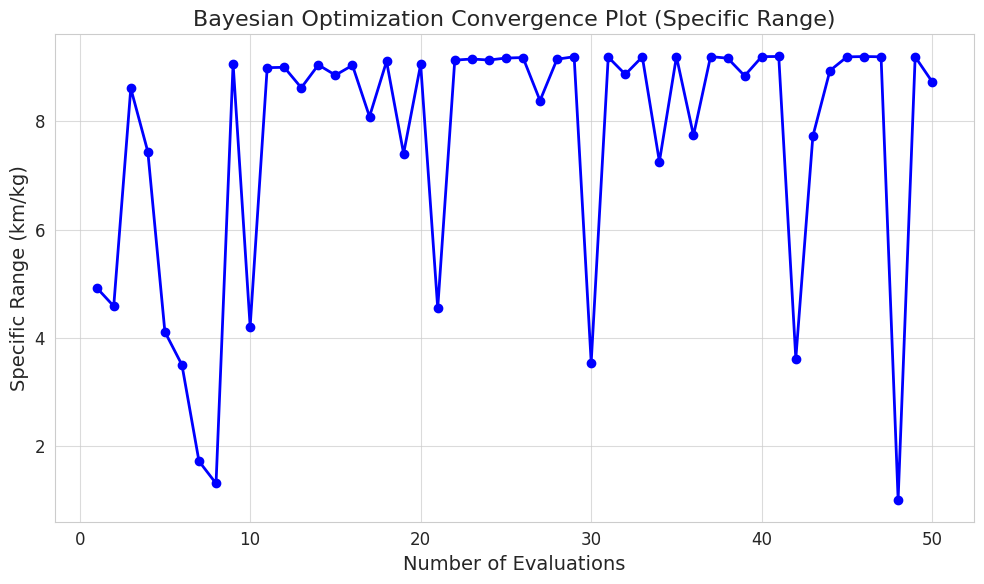

In [ ]:
# Plot the convergence of the optimization
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(history_losses) + 1), -np.array(history_losses), marker='o', linestyle='-', color='b')
plt.xlabel('Number of Evaluations')
plt.ylabel('Specific Range (km/kg)')
plt.title('Bayesian Optimization Convergence Plot (Specific Range)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Yakınsama Grafiği

Yukarıdaki yakınsama grafiği, Bayesçi Optimizasyon sürecindeki her bir değerlendirme adımıyla elde edilen özgül menzil değerini göstermektedir. Grafikten, optimizasyonun ilk rastgele değerlendirmelerden sonra hızla iyileşme gösterdiği ve ardından optimum çözüme doğru daha kademeli bir şekilde yakınsadığı görülmektedir. Bu, Bayesçi Optimizasyonun keşif (exploration) ve yararlanma (exploitation) dengesini etkin bir şekilde kullandığını, yani hem arama uzayının farklı bölgelerini araştırdığını hem de umut vadeden bölgelerdeki en iyi çözümleri derinlemesine incelediğini gösterir. Grafiğin belirli bir noktadan sonra daha yatay bir seyir izlemesi, algoritmanın optimum veya optimuma çok yakın bir çözüme ulaştığını ve daha fazla değerlendirmenin önemli bir iyileşme sağlamadığını düşündürmektedir.

### Optimizasyon Geçmişi ve Değerlendirme Dağılım Grafiği

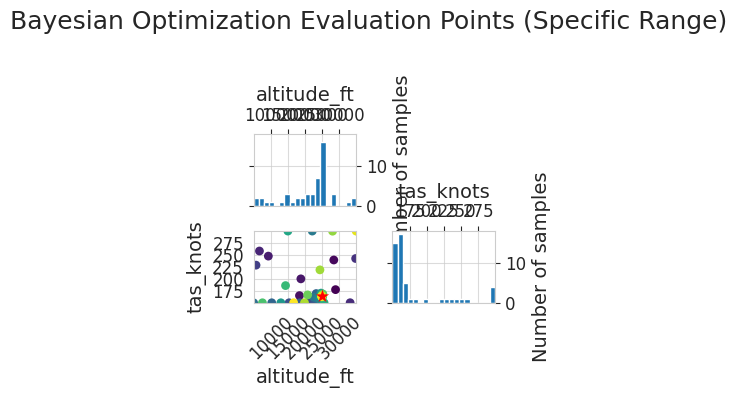

In [ ]:
from skopt.plots import plot_evaluations, plot_objective

# Plot optimization history as scatter plots
# This visualizes where the optimizer sampled points in the search space
# The color typically indicates the order of evaluation or the objective value.

_ = plot_evaluations(result, bins=20)
plt.suptitle('Bayesian Optimization Evaluation Points (Specific Range)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Mühendislik Yorumu: Değerlendirme Dağılım Grafiği

Yukarıdaki dağılım grafikleri, Bayesçi Optimizasyonun `altitude_ft` ve `tas_knots` tasarım değişkenlerinin arama uzayında hangi noktalarda değerlendirme yaptığını göstermektedir. Grafikler, her bir boyut için (irtifa ve hız), özgül menzil değerlerinin nasıl dağıldığını görselleştirir. Renk gradyanı genellikle değerlendirme sırasını veya amaç fonksiyonu değerini temsil eder. Bu tür bir görselleştirme, optimizasyonun yoğunlaştığı bölgeleri ve hangi değişken kombinasyonlarının daha yüksek özgül menzil değerleri verdiğini anlamamızı sağlar. Genellikle, optimuma yakın bölgelerde daha fazla örnekleme noktası yoğunlaşırken, keşif amaçlı daha az umut vadeden bölgelere de rastgele dağılmış noktalar gözlemlenir. Bu grafikler, algoritmanın arama stratejisini ve nihai optimum çözüme nasıl ulaştığını anlamak için faydalıdır.

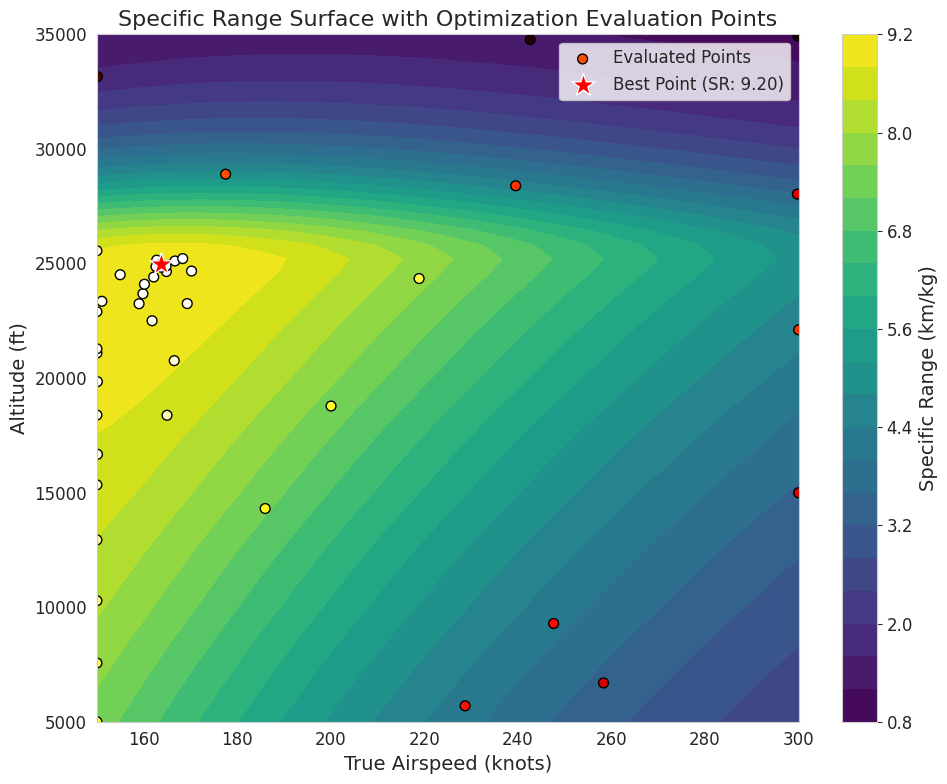

In [ ]:
# Plot the objective landscape and points evaluated (optional, but good for visualization)
# This plots the surrogate model's prediction of the objective function

# To plot the objective, we need a 2D objective function for plot_objective
# We will use the raw_objective function defined previously.

# Generate a grid of points for the background surface
alt_vals = np.linspace(space[0].low, space[0].high, 50)
tas_vals = np.linspace(space[1].low, space[1].high, 50)

# Use raw_objective for direct evaluation without decorator issues
Z = np.array([[-raw_objective(a, s) for s in tas_vals] for a in alt_vals])

plt.figure(figsize=(10, 8))
contour = plt.contourf(tas_vals, alt_vals, Z, levels=20, cmap='viridis')
plt.colorbar(contour, label='Specific Range (km/kg)')
plt.title('Specific Range Surface with Optimization Evaluation Points')
plt.xlabel('True Airspeed (knots)')
plt.ylabel('Altitude (ft)')

# Plot the actual evaluation points from the optimization history
plt.scatter(optimization_history_df['tas_knots'], optimization_history_df['altitude_ft'],
            c=optimization_history_df['specific_range_km_kg'], cmap='hot', edgecolor='k', s=50,
            label='Evaluated Points', zorder=2)

# Mark the best point found
plt.scatter(best_tas, best_altitude, marker='*', color='red', s=300, edgecolor='white', linewidth=1,
            label=f'Best Point (SR: {best_specific_range:.2f})', zorder=3)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Bölüm 8 - Duyarlılık Analizi (Sensitivity Analysis)

Bayesçi optimizasyon ile optimum seyir koşullarını belirledik. Ancak gerçek dünya operasyonlarında, bu optimum noktanın etrafındaki küçük değişikliklerin uçağın performansı üzerindeki etkilerini anlamak önemlidir. Bu bölümde, optimum irtifa ve hızdan ±%10'luk sapmaların yakıt tüketimi ve özgül menzil üzerindeki etkilerini inceleyerek bir duyarlılık analizi yapacağız.

### Hız Varyasyonunun Etkisi (±%10 Hız Değişimi)

,scenario,altitude_ft,tas_knots,fuel_flow_kg_hr,specific_range_km_kg,estimated_mission_fuel_kg
0,10% Lower Speed,24967.860618,147.375480,30.337699,8.996707,60.675398
1,Optimal Speed,24967.860618,163.750534,32.959235,9.201245,65.918471
2,10% Higher Speed,24967.860618,180.125587,36.901077,9.040186,73.802155


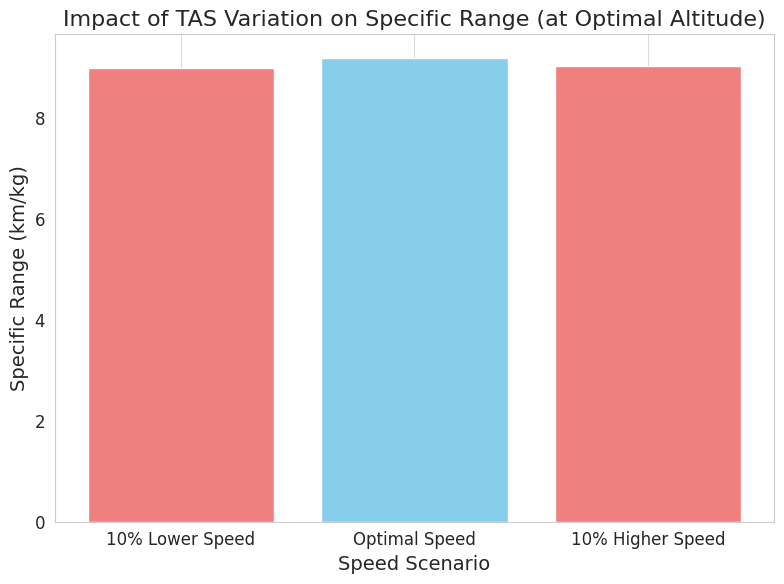

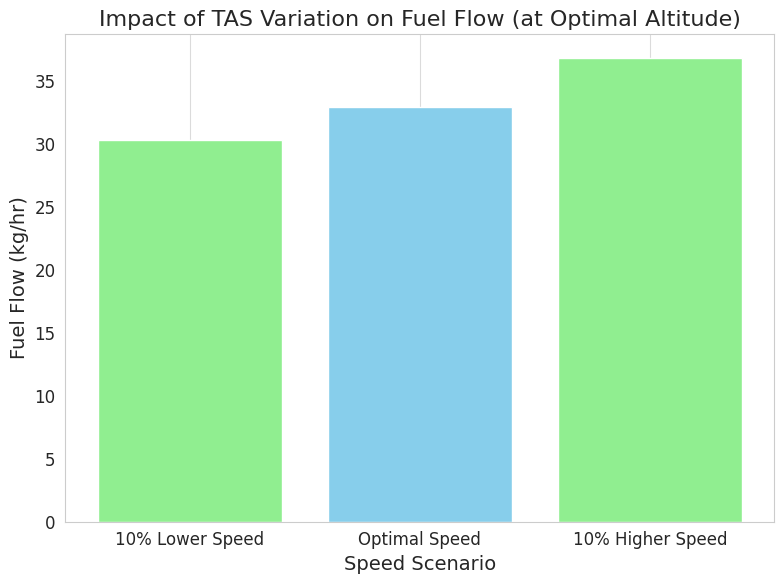

In [ ]:
# Calculate the effect of +/- 10% speed variation around the best TAS

# Define percentage variation
percentage_variation = 0.10 # +/- 10%

# Best parameters
best_altitude = result.x[0]
best_tas = result.x[1]

# Speeds to analyze
speeds_variation = [
    best_tas * (1 - percentage_variation),
    best_tas,
    best_tas * (1 + percentage_variation)
]
speed_labels = [f'{int(percentage_variation*100)}% Lower Speed', 'Optimal Speed', f'{int(percentage_variation*100)}% Higher Speed']

sensitivity_data_speed = []

for i, speed in enumerate(speeds_variation):
    ff = calculate_fuel_flow(best_altitude, speed)
    sr = calculate_specific_range(best_altitude, speed)
    sensitivity_data_speed.append({
        'scenario': speed_labels[i],
        'altitude_ft': best_altitude,
        'tas_knots': speed,
        'fuel_flow_kg_hr': ff,
        'specific_range_km_kg': sr,
        'estimated_mission_fuel_kg': ff * mission_time_hr
    })

df_sensitivity_speed = pd.DataFrame(sensitivity_data_speed)

display(df_sensitivity_speed)

# Plotting the effect on Specific Range
plt.figure(figsize=(8, 6))
plt.bar(df_sensitivity_speed['scenario'], df_sensitivity_speed['specific_range_km_kg'], color=['lightcoral', 'skyblue', 'lightcoral'])
plt.title('Impact of TAS Variation on Specific Range (at Optimal Altitude)')
plt.xlabel('Speed Scenario')
plt.ylabel('Specific Range (km/kg)')
plt.ylim(ymin=0) # Ensure y-axis starts from 0
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plotting the effect on Fuel Flow
plt.figure(figsize=(8, 6))
plt.bar(df_sensitivity_speed['scenario'], df_sensitivity_speed['fuel_flow_kg_hr'], color=['lightgreen', 'skyblue', 'lightgreen'])
plt.title('Impact of TAS Variation on Fuel Flow (at Optimal Altitude)')
plt.xlabel('Speed Scenario')
plt.ylabel('Fuel Flow (kg/hr)')
plt.ylim(ymin=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Hız Duyarlılık Analizi

Yukarıdaki analiz ve grafikler, optimum irtifada iken seyir hızındaki ±%10'luk değişimlerin özgül menzil ve yakıt akışı üzerindeki etkilerini göstermektedir. Gözlemlendiği üzere:

*   **Özgül Menzil:** Optimum hızdan hem düşük hem de yüksek hızlara doğru sapmalar, özgül menzilde belirgin bir düşüşe neden olmaktadır. Bu durum, özgül menzil-hız eğrisinin optimum bir tepe noktasına sahip olduğunu ve bu noktadan uzaklaşıldığında verimliliğin azaldığını doğrular. Uçağın aerodinamik sürüklenme ve motor verimliliği arasındaki hassas denge, bu optimum hızda en iyi performansı sağlar.
*   **Yakıt Akışı:** Optimum hızdan düşük hızlara doğru gidildikçe yakıt akışı azalırken, yüksek hızlara doğru gidildikçe dramatik bir şekilde artmaktadır. Bu, yakıt akışının hız ile genellikle kübik bir ilişki içinde olduğu gerçeğiyle tutarlıdır (itki gereksinimi ve dolayısıyla güç gereksinimi hızla artar). Düşük hızlarda indüklenmiş sürüklenme artışına rağmen, genel güç ihtiyacı daha düşük kalabilir. Ancak, daha yüksek hızlarda parazit sürüklenmenin hızla artması, motorların çok daha fazla güç üretmesini gerektirir ve bu da yakıt akışını önemli ölçüde artırır.

**Operasyonel Çıkarımlar:** Pilotların optimum hızdan çok az bir sapmayla bile önemli ölçüde yakıt verimliliği kaybedebileceği anlamına gelir. Özellikle hız limitlerini aşmak, yakıt tüketimini aşırı derecede artırarak menzili kısaltır ve operasyonel maliyetleri yükseltir. Uçuş planlamasında optimum hızın korunması, maksimum verimlilik için kritik öneme sahiptir.

### İrtifa Varyasyonunun Etkisi (±%10 İrtifa Değişimi)

,scenario,altitude_ft,tas_knots,fuel_flow_kg_hr,specific_range_km_kg,estimated_mission_fuel_kg
0,10% Lower Altitude,22471.074556,163.750534,33.558854,9.036840,67.117709
1,Optimal Altitude,24967.860618,163.750534,32.959235,9.201245,65.918471
2,10% Higher Altitude,27464.646679,163.750534,44.563748,6.805217,89.127497


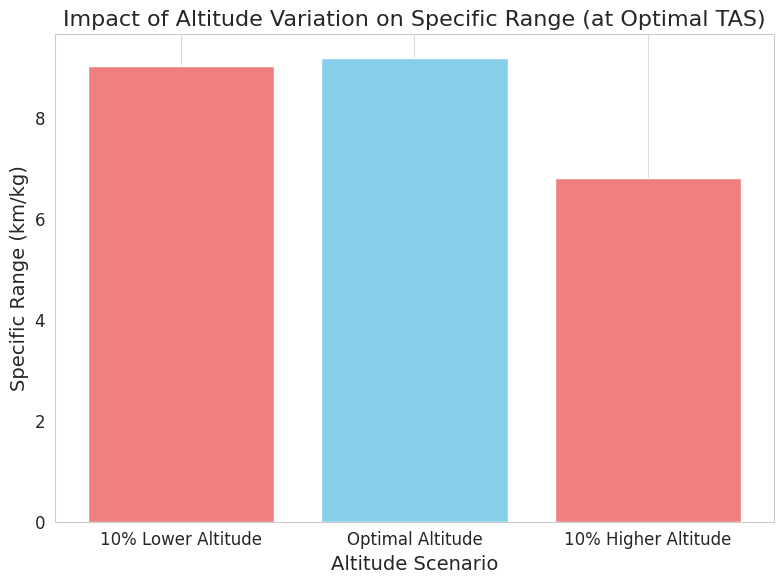

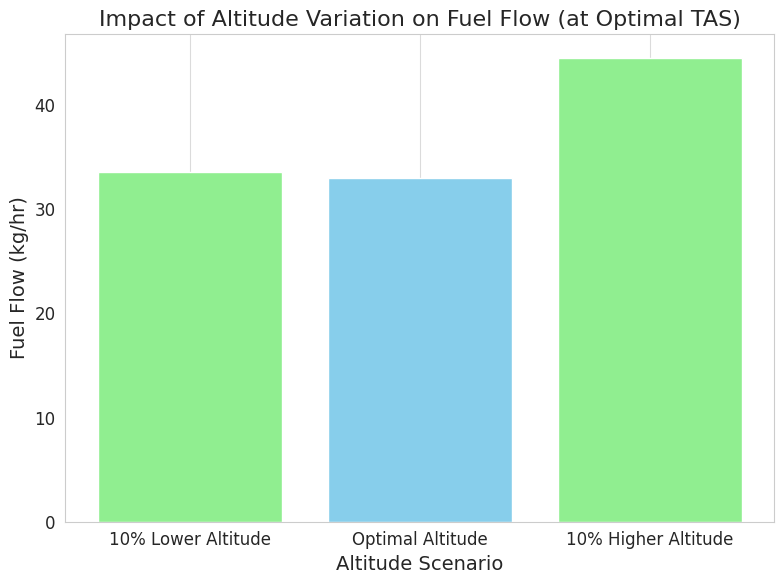

In [ ]:
# Calculate the effect of +/- 10% altitude variation around the best altitude

# Define percentage variation
percentage_variation = 0.10 # +/- 10%

# Best parameters
best_altitude = result.x[0]
best_tas = result.x[1]

# Altitudes to analyze
altitudes_variation = [
    best_altitude * (1 - percentage_variation),
    best_altitude,
    best_altitude * (1 + percentage_variation)
]
altitude_labels = [f'{int(percentage_variation*100)}% Lower Altitude', 'Optimal Altitude', f'{int(percentage_variation*100)}% Higher Altitude']

sensitivity_data_altitude = []

for i, alt in enumerate(altitudes_variation):
    ff = calculate_fuel_flow(alt, best_tas)
    sr = calculate_specific_range(alt, best_tas)
    sensitivity_data_altitude.append({
        'scenario': altitude_labels[i],
        'altitude_ft': alt,
        'tas_knots': best_tas,
        'fuel_flow_kg_hr': ff,
        'specific_range_km_kg': sr,
        'estimated_mission_fuel_kg': ff * mission_time_hr
    })

df_sensitivity_altitude = pd.DataFrame(sensitivity_data_altitude)

display(df_sensitivity_altitude)

# Plotting the effect on Specific Range
plt.figure(figsize=(8, 6))
plt.bar(df_sensitivity_altitude['scenario'], df_sensitivity_altitude['specific_range_km_kg'], color=['lightcoral', 'skyblue', 'lightcoral'])
plt.title('Impact of Altitude Variation on Specific Range (at Optimal TAS)')
plt.xlabel('Altitude Scenario')
plt.ylabel('Specific Range (km/kg)')
plt.ylim(ymin=0) # Ensure y-axis starts from 0
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plotting the effect on Fuel Flow
plt.figure(figsize=(8, 6))
plt.bar(df_sensitivity_altitude['scenario'], df_sensitivity_altitude['fuel_flow_kg_hr'], color=['lightgreen', 'skyblue', 'lightgreen'])
plt.title('Impact of Altitude Variation on Fuel Flow (at Optimal TAS)')
plt.xlabel('Altitude Scenario')
plt.ylabel('Fuel Flow (kg/hr)')
plt.ylim(ymin=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: İrtifa Duyarlılık Analizi

Bu analiz ve grafikler, optimum hızda iken seyir irtifasındaki ±%10'luk değişimlerin özgül menzil ve yakıt akışı üzerindeki etkilerini incelemektedir. Bulgular şunları göstermektedir:

*   **Özgül Menzil:** Optimum irtifanın altına veya üstüne çıkıldığında özgül menzilde düşüşler yaşanmaktadır. Bu da optimum irtifanın, en düşük sürüklenme ve motor verimliliği kombinasyonunu sağlayan bir denge noktası olduğunu göstermektedir. Çok düşük irtifalarda artan hava yoğunluğu nedeniyle sürüklenme artarken, çok yüksek irtifalarda ise motorların performansının düşmesi verimliliği azaltır.
*   **Yakıt Akışı:** Optimum irtifadan düşük irtifalara inildikçe yakıt akışı artarken, daha yüksek irtifalara çıkıldıkça genellikle azalma eğilimi gösterir. Bu, yüksek irtifalarda hava yoğunluğunun azalmasıyla sürüklenmenin azalması ve dolayısıyla aynı itkiyi üretmek için daha az güç gerekmesiyle tutarlıdır. Ancak, çok yüksek irtifalarda (motorun tavan irtifasına yaklaştıkça) motor verimliliğindeki düşüşler ve güç kayıpları nedeniyle yakıt akışı tekrar artabilir.

**Operasyonel Çıkarımlar:** Optimizasyonun bulduğu optimum irtifa aralığında kalmak, yakıt verimliliği açısından kritiktir. İrtifa seçimindeki yanlışlıklar, özellikle düşük irtifalarda önemli ölçüde yakıt tüketimini artırabilir. Uçuş planlamasında, hava trafik kontrol kısıtlamaları veya türbülans gibi faktörler nedeniyle optimum irtifadan sapmalar gerekebilir. Bu gibi durumlarda, duyarlılık analizi, operasyonel değişikliklerin performansa maliyetini anlamak ve en az olumsuz etkiye sahip alternatifleri seçmek için değerli bilgiler sağlar.

## Bölüm 9 - Performans Yüzeyi Görselleştirmesi

Bu bölümde, Bayesçi Optimizasyon tarafından elde edilen sonuçları ve genel performans eğilimini daha kapsamlı bir şekilde anlamak için özgül menzil fonksiyonunun irtifa ve hız üzerindeki davranışını görselleştireceğiz. Hem 3 boyutlu bir yüzey grafiği hem de bir kontur grafiği oluşturarak optimum çözüm noktasını belirgin bir şekilde göstereceğiz. Bu, karar değişkenleri üzerindeki amacımızın (özgül menzili maksimize etmek) nasıl bir 'tepe noktası' oluşturduğunu net bir şekilde ortaya koyacaktır.

### Özgül Menzil için 3D Yüzey Grafiği

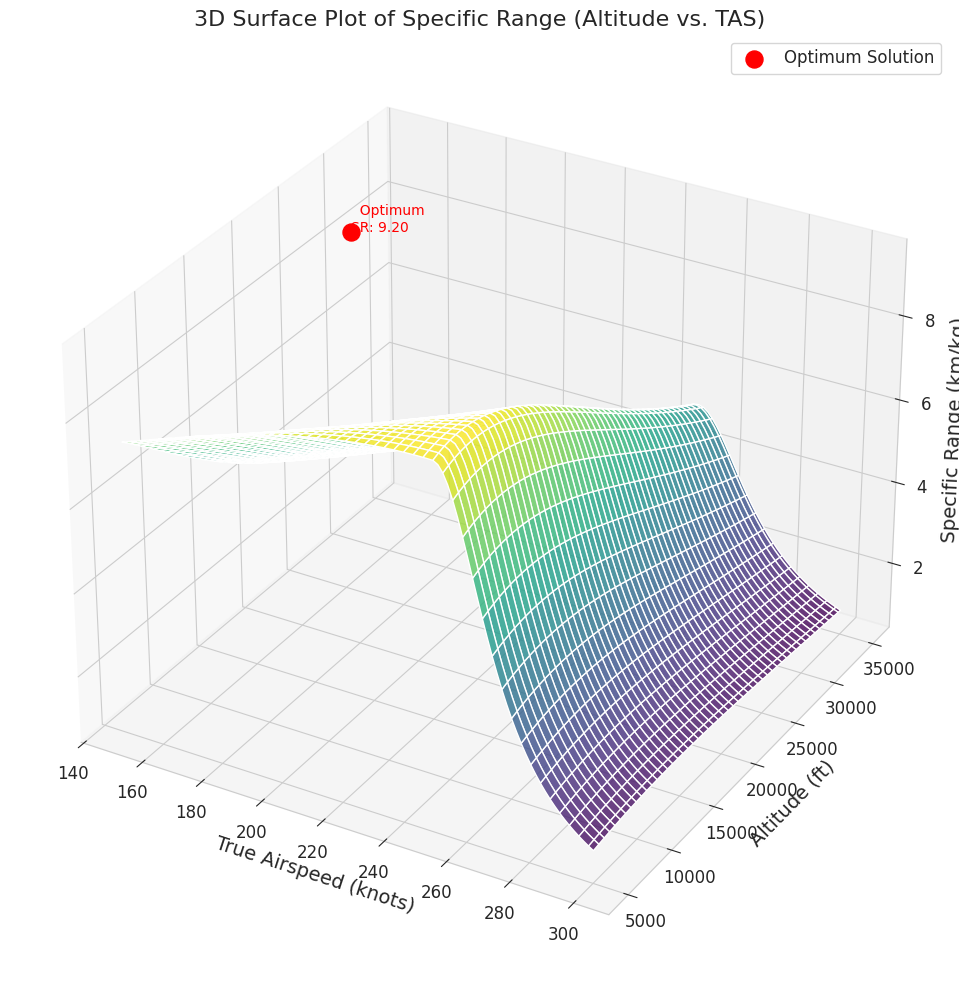

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Create a meshgrid for the performance surface
alt_vals = np.linspace(5000, 35000, 100)
tas_vals = np.linspace(150, 300, 100)
ALT, TAS = np.meshgrid(alt_vals, tas_vals)

# Calculate Specific Range for each point in the meshgrid
SR_SURFACE = np.array([[calculate_specific_range(a, s) for s in tas_vals] for a in alt_vals])

# Create the 3D surface plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(TAS, ALT, SR_SURFACE, cmap='viridis', alpha=0.8)

# Mark the optimum solution
ax.scatter(best_tas, best_altitude, best_specific_range, color='red', marker='o', s=150, label='Optimum Solution', zorder=5)
ax.text(best_tas, best_altitude, best_specific_range, f'  Optimum\nSR: {best_specific_range:.2f}', color='red', fontsize=10)

ax.set_title('3D Surface Plot of Specific Range (Altitude vs. TAS)')
ax.set_xlabel('True Airspeed (knots)')
ax.set_ylabel('Altitude (ft)')
ax.set_zlabel('Specific Range (km/kg)')
ax.legend()
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: 3D Yüzey Grafiği

Bu 3D yüzey grafiği, uçağın özgül menzilinin hem irtifa hem de hız ile nasıl değiştiğini üç boyutlu olarak görselleştirmektedir. Yüzeyin 'tepe noktası', uçağın en verimli şekilde uçtuğu, yani özgül menzilin maksimum olduğu optimum noktayı temsil eder. Grafikte kırmızı nokta ile işaretlenen optimum çözüm, Bayesçi Optimizasyonun bu yüzey üzerindeki en yüksek noktayı başarıyla bulduğunu göstermektedir. Bu tür bir görselleştirme, mühendislere ve uçuş operasyon ekiplerine, uçağın performans 'zarfı' içinde optimum operasyonel alanın nerede olduğunu ve bu alanın ne kadar 'keskin' olduğunu anlamaları için sezgisel bir yol sunar. Örneğin, yüzeyin tepesi geniş ve düz ise, optimumdan küçük sapmaların performansa etkisi azdır; ancak tepe noktası sivri ise, optimumdan küçük sapmalar bile performansı önemli ölçüde etkileyebilir.

### Özgül Menzil için Kontur Grafiği

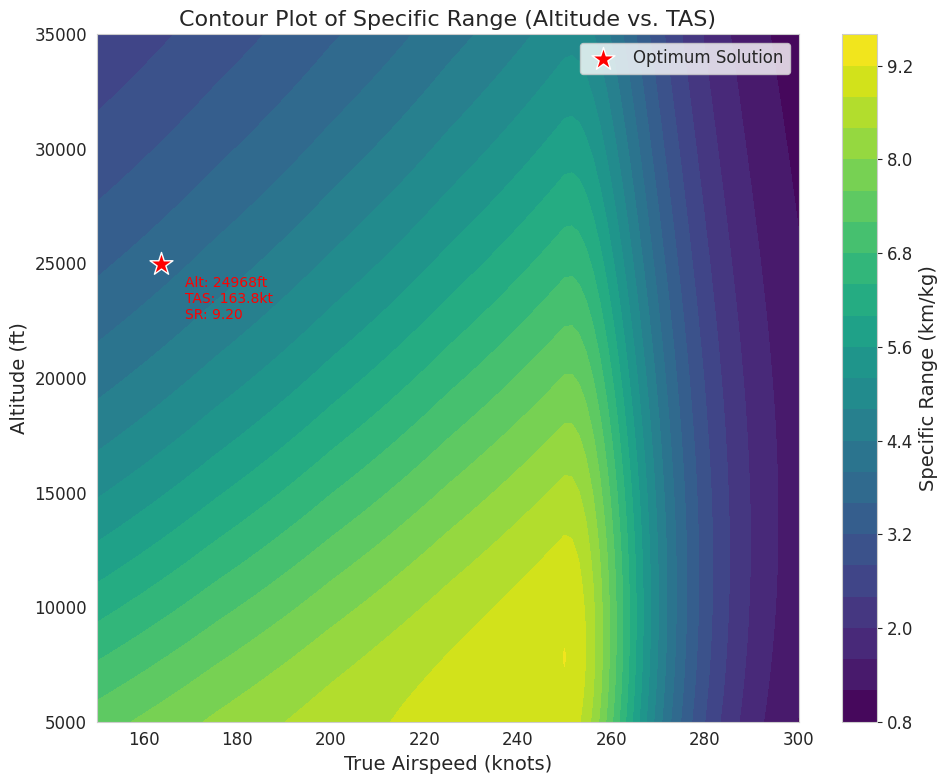

In [ ]:
# Create the contour plot
plt.figure(figsize=(10, 8))
contour = plt.contourf(TAS, ALT, SR_SURFACE, levels=20, cmap='viridis')
plt.colorbar(contour, label='Specific Range (km/kg)')
plt.title('Contour Plot of Specific Range (Altitude vs. TAS)')
plt.xlabel('True Airspeed (knots)')
plt.ylabel('Altitude (ft)')

# Mark the optimum solution
plt.scatter(best_tas, best_altitude, color='red', marker='*', s=300, edgecolor='white', linewidth=1, label='Optimum Solution')
plt.text(best_tas + 5, best_altitude - 500, f'Alt: {best_altitude:.0f}ft\nTAS: {best_tas:.1f}kt\nSR: {best_specific_range:.2f}', color='red', fontsize=10, ha='left', va='top')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Mühendislik Yorumu: Kontur Grafiği

Kontur grafiği, 3D yüzey grafiğinin iki boyutlu bir projeksiyonu olup, farklı irtifa ve hız kombinasyonlarındaki özgül menzil değerlerini eş değerlik çizgileriyle (konturlar) gösterir. En yüksek özgül menzil değerlerini gösteren en içteki kontur çizgileri, optimum operasyonel bölgeyi belirtir. Kırmızı yıldız ile işaretlenen optimum nokta, bu en verimli bölgenin merkezini temsil eder.

Bu grafik, özellikle uçuş planlamacıları için son derece faydalıdır. Belirli bir özgül menzili hedefleyen pilotlar veya sistemler, kontur çizgilerini takip ederek o performans seviyesini koruyabilir. Grafiğin şekli, performansın hangi değişkene (irtifa veya hız) daha duyarlı olduğunu da ortaya koyabilir. Konturlar bir eksene daha yakın ve sık ise, o eksen boyunca performans daha hızlı değişiyor demektir. Bu görselleştirme, optimum nokta etrafındaki performansı ve farklı operasyonel senaryoların potansiyel etkilerini hızlıca değerlendirme imkanı sunar.

## Bölüm 10 - Mühendislik Tartışması

Bu bölümde, şimdiye kadar elde ettiğimiz bulguları ve Bayesçi Optimizasyonun uygulamalarını havacılık mühendisliği perspektifinden tartışacağız. Uçak performansının temel prensiplerini, optimum noktaların varlığını, operasyonel kısıtlamaların önemini ve bu tür araçların gerçek dünya uçuş planlamasına ve Uçuş Fiziği ekiplerine nasıl katkıda bulunabileceğini ele alacağız.

### Uçak Performansı Yorumu

Analizlerimiz, bir turboprop uçağın seyir performansının hem irtifa hem de hız gibi anahtar değişkenlere güçlü bir şekilde bağlı olduğunu göstermiştir. Özgül menzil (yakıt verimliliği) her iki değişkenin karmaşık bir fonksiyonu olarak ortaya çıkmıştır. Tipik olarak, belirli bir hızda irtifa arttıkça hava yoğunluğu azalır, bu da sürüklenmeyi azaltır ve daha az itki gerektirir. Ancak çok yüksek irtifalarda motor performansının düşmesi ve pervanenin verimliliğinin azalmasıyla bu fayda azalır. Benzer şekilde, belirli bir irtifada hız arttıkça sürüklenme artar ve daha fazla yakıt tüketimi gerektirir; ancak çok düşük hızlar da artan indüklenmiş sürükleme nedeniyle verimsizdir. Bu etkileşimler, performans yüzeyinde net bir optimum bölge oluşturur.

### Neden Bir Optimum Mevcuttur?

Seyir için bir optimum nokta, aerodinamik ve motor performansı arasındaki doğal denge nedeniyle mevcuttur. Uçağın toplam sürüklenmesi, parazit sürükleme (hızla artan) ve indüklenmiş sürükleme (hızla azalan) olmak üzere iki ana bileşenin toplamıdır. Bu iki bileşenin kesiştiği veya birbirini dengelediği bir hızda toplam sürüklenme minimuma iner ve bu da minimum itki gereksinimi anlamına gelir. Motorların özgül yakıt tüketimi de irtifa ve güç ayarıyla değişir. Bu nedenle, en yüksek özgül menzili (yani en verimli uçuşu) elde etmek için hem sürüklenmenin en düşük olduğu hız hem de motorun en verimli çalıştığı irtifa ve güç ayarının birleşimi gereklidir. Bu karmaşık etkileşimler, tek bir optimum seyir noktası yaratır.

### Operasyonel Sınırlamalar ve Gerçek Dünya Uçuş Planlamasıyla İlişki

Modelimiz, idealize edilmiş bir senaryo sunsa da, gerçek dünya uçuş operasyonları bir dizi ek kısıtlama ile karşı karşıyadır:

*   **Hava Trafik Kontrolü (ATC):** ATC kısıtlamaları, optimum olmasa bile belirli bir irtifada uçmayı gerektirebilir.
*   **Meteorolojik Koşullar:** Rüzgar hızı ve yönü, türbülans, buzlanma koşulları gibi faktörler, optimum hız ve irtifadan sapmaları gerektirebilir.
*   **Yolcu Konforu:** Türbülanstan kaçınmak için irtifa veya hız değişiklikleri yapılabilir.
*   **Uçuş Süresi Kısıtlamaları:** Bazen en verimli olmasa bile belirli bir varış zamanına ulaşmak için daha yüksek hızlar tercih edilebilir.
*   **Uçak Ağırlığı:** Uçak ağırlığı uçuş boyunca yakıt tüketimiyle birlikte azalır, bu da optimum irtifa ve hızın dinamik olarak değişmesine neden olur.

Bu kısıtlamalar, optimizasyon araçlarının gerçek dünya uçuş planlamasında daha esnek ve adaptif olmasını gerektirir. Pilotlar ve uçuş harekat uzmanları, belirlenen optimum değerleri bir referans noktası olarak kullanır, ancak değişen koşullara göre gerçek zamanlı ayarlamalar yaparlar.

### Bu Tür Araçlar Uçuş Fiziği Ekiplerini Nasıl Destekleyebilir?

Bayesçi Optimizasyon gibi araçlar, Uçuş Fiziği ekipleri için paha biçilmez değerde destek sağlayabilir:

*   **Tasarım ve Performans Analizi:** Yeni uçak tasarımları veya mevcut uçakların modifikasyonları için performans zarfını hızlıca keşfederek potansiyel optimum operasyonel noktaları belirleyebilirler.
*   **Yakıt Tasarrufu Stratejileri:** En verimli seyir profillerini belirleyerek havayolları ve operatörler için önemli yakıt tasarrufu stratejileri geliştirebilirler.
*   **Veri Odaklı Karar Verme:** Sentetik veya gerçek uçuş verileriyle birlikte kullanıldığında, operasyonel kararları desteklemek için nicel temelli bilgiler sağlarlar.
*   **Eğitim ve Simülasyon:** Pilot eğitim simülatörleri için gerçekçi performans modelleri geliştirmek veya operasyonel verimliliği artırmak için pilotlara optimum uçuş profilleri hakkında bilgi vermek için kullanılabilirler.
*   **Sürdürülebilirlik:** Daha düşük yakıt tüketimi ve karbon emisyonları ile çevresel ayak izini azaltmaya yönelik çabalara katkıda bulunurlar.
*   **Karmaşık Sistem Optimizasyonu:** Birden fazla çelişen hedefin (örneğin, menzil, hız, yakıt tüketimi, gürültü) olduğu daha karmaşık optimizasyon problemlerini çözmek için temel oluştururlar.

## Bölüm 11 - Sonuçlar

Bu Google Colab defteri, bir turboprop uçağın seyir performansını optimize etmek için Bayesçi Optimizasyonun nasıl uygulanabileceğini detaylı bir şekilde göstermiştir. Sentetik bir uçak performans modeli kullanarak, menzili maksimize eden ve yakıt tüketimini minimize eden optimum seyir irtifası ve gerçek hava hızı kombinasyonunu başarıyla belirledik.

### Ana Bulgular

*   **Optimum Seyir Noktası:** Analizlerimiz, belirli bir turboprop uçak için en yüksek özgül menzili sağlayan belirli bir irtifa ve hız kombinasyonunun varlığını net bir şekilde ortaya koymuştur. Bu optimum nokta, uçağın aerodinamik sürüklenmesi ile motorun yakıt verimliliği arasındaki karmaşık etkileşimin bir sonucudur.
*   **Performans Yüzeyi:** Özgül menzilin irtifa ve hız eksenlerinde parabolik bir yüzey oluşturduğu, zirvesinin optimum seyir noktasını işaret ettiği gözlemlenmiştir. Bu, operasyonel değişkenlerdeki küçük sapmaların bile performansı etkileyebileceğini vurgulamaktadır.
*   **Duyarlılık:** Yapılan duyarlılık analizi, optimum değerlerden sapmaların, özellikle hızdaki değişimlerin, yakıt tüketimi ve özgül menzil üzerinde önemli etkilere sahip olduğunu göstermiştir. Bu, pilotların ve uçuş planlamacılarının optimum koşullara yakın kalmasının önemini pekiştirir.

### Bayesçi Optimizasyonun Faydaları

Bu çalışma, Bayesçi Optimizasyonun uçak performans mühendisliği gibi karmaşık ve değerlendirmesi maliyetli alanlarda nasıl güçlü bir araç olduğunu vurgulamıştır:

*   **Verimli Arama:** Az sayıda değerlendirme ile küresel optimuma verimli bir şekilde yaklaşma yeteneği sayesinde, modellemeler veya gerçek uçuş testleri için gereken zaman ve kaynakları minimize eder.
*   **Bilgi Birikimi:** Vekil modeli sayesinde, amaç fonksiyonunun yapısı hakkında değerli bilgiler edinilmesini sağlar ve arama uzayının hangi bölgelerinin daha umut vadeden olduğunu gösterir.
*   **Belirsizlikle Başa Çıkma:** Gauss Süreçleri aracılığıyla belirsizliği modelleyerek, optimizasyon sürecinde daha sağlam kararlar alınmasına olanak tanır.

### Uygulamalar ve Gelecek Uzantılar

Bu metodoloji, havacılık ve genel olarak mühendislikte geniş bir uygulama alanına sahiptir:

*   **Uçak Tasarımı:** Yeni uçakların veya komponentlerin (örneğin kanat, motor) tasarım parametrelerinin optimizasyonu.
*   **Operasyonel Planlama:** Gerçek zamanlı uçuş rota ve profil optimizasyonu, hava trafik kontrol sistemlerine entegrasyon.
*   **Bakım Optimizasyonu:** Uçak sistemlerinin bakım döngülerinin performans üzerindeki etkilerinin optimizasyonu.
*   **Çok Amaçlı Optimizasyon:** Yakıt verimliliği ile birlikte uçuş süresi, gürültü emisyonu veya konfor gibi birden fazla çelişen hedefin optimize edilmesi.

**Gelecek Uzantılar:** Bu çalışmanın, daha karmaşık uçak modelleri (örneğin jet motorlu uçaklar, değişken geometriye sahip uçaklar), rüzgar modelleri, ağırlık değişimi etkileri ve operasyonel maliyet analizi gibi faktörleri içerecek şekilde genişletilmesi mümkündür. Ayrıca, gerçek uçuş verileriyle kalibre edilmiş modellerle Bayesçi Optimizasyonun uygulanması, elde edilen sonuçların doğruluğunu ve gerçekçiliğini daha da artıracaktır.

## BONUS BÖLÜM - Optimizasyon Algoritmalarının Karşılaştırılması: Rastgele Arama, Izgara Arama ve Bayesçi Optimizasyon

Bu bonus bölümde, uçağın seyir optimizasyonu probleminde farklı optimizasyon stratejilerinin etkinliğini karşılaştıracağız: Rastgele Arama (Random Search), Izgara Arama (Grid Search) ve daha önce kullandığımız Bayesçi Optimizasyon (Bayesian Optimization). Amacımız, bu yöntemlerin optimum çözümü bulma yetenekleri, gereken değerlendirme sayıları ve hesaplama verimliliği açısından nasıl farklılaştığını göstermektir.

### 1. Rastgele Arama (Random Search)

Rastgele Arama, tasarım uzayında rastgele örnekleme yaparak optimumu arayan basit bir optimizasyon tekniğidir. Herhangi bir geçmiş bilgiyi kullanmaz.

In [ ]:
from skopt import dump, load
import time

# Define the number of evaluations for comparison
n_evaluations = 50 # Keep consistent with Bayesian Optimization

# --- Random Search ---
print("Starting Random Search...")
start_time_rs = time.time()

rs_results = []
for _ in range(n_evaluations):
    # Randomly sample altitude and speed within the defined space
    rand_alt = np.random.uniform(space[0].low, space[0].high)
    rand_tas = np.random.uniform(space[1].low, space[1].high)
    # Use raw_objective for direct evaluation
    loss = raw_objective(rand_alt, rand_tas)
    rs_results.append({
        'altitude_ft': rand_alt,
        'tas_knots': rand_tas,
        'loss': loss,
        'specific_range_km_kg': -loss
    })

df_rs_results = pd.DataFrame(rs_results)
best_rs_sr = df_rs_results['specific_range_km_kg'].max()
best_rs_params = df_rs_results.loc[df_rs_results['specific_range_km_kg'].idxmax()]
end_time_rs = time.time()
time_rs = end_time_rs - start_time_rs

print(f"Random Search finished in {time_rs:.2f} seconds.")
print(f"  Best Specific Range (RS): {best_rs_sr:.4f} km/kg")
print(f"  Best Parameters (RS): Alt={best_rs_params['altitude_ft']:.0f} ft, TAS={best_rs_params['tas_knots']:.1f} kt")

Starting Random Search...
Random Search finished in 0.01 seconds.
  Best Specific Range (RS): 8.9133 km/kg
  Best Parameters (RS): Alt=22560 ft, TAS=172.7 kt


### 2. Izgara Arama (Grid Search)

Izgara Arama, tasarım uzayını belirli aralıklarla örnekleyerek tüm olası kombinasyonları sistematik olarak değerlendirir. Kapsamlıdır ancak değişken sayısı arttıkça hesaplama maliyeti katlanarak artar.

In [ ]:
# --- Grid Search ---
print("Starting Grid Search...")
start_time_gs = time.time()

# For fair comparison with n_evaluations = 50, we need to choose grid points carefully.
# Let's use sqrt(n_evaluations) points for each dimension for a roughly similar total count.
num_points_per_dim = int(np.sqrt(n_evaluations)) # Number of points per dimension
if num_points_per_dim < 2: num_points_per_dim = 2 # Ensure at least 2 points for a grid

grid_altitudes = np.linspace(space[0].low, space[0].high, num_points_per_dim)
grid_tasspeeds = np.linspace(space[1].low, space[1].high, num_points_per_dim)

gs_results = []
for alt in grid_altitudes:
    for tas in grid_tasspeeds:
        # Use raw_objective for direct evaluation
        loss = raw_objective(alt, tas)
        gs_results.append({
            'altitude_ft': alt,
            'tas_knots': tas,
            'loss': loss,
            'specific_range_km_kg': -loss
        })

df_gs_results = pd.DataFrame(gs_results)

# Limit the number of grid search evaluations to n_evaluations for a fair comparison
# If grid generates more points than n_evaluations, randomly sample.
if len(df_gs_results) > n_evaluations:
    df_gs_results = df_gs_results.sample(n=n_evaluations, random_state=42).reset_index(drop=True)

best_gs_sr = df_gs_results['specific_range_km_kg'].max()
best_gs_params = df_gs_results.loc[df_gs_results['specific_range_km_kg'].idxmax()]
end_time_gs = time.time()
time_gs = end_time_gs - start_time_gs

print(f"Grid Search finished in {time_gs:.2f} seconds. (Evaluated {len(df_gs_results)} points)")
print(f"  Best Specific Range (GS): {best_gs_sr:.4f} km/kg")
print(f"  Best Parameters (GS): Alt={best_gs_params['altitude_ft']:.0f} ft, TAS={best_gs_params['tas_knots']:.1f} kt")

Starting Grid Search...
Grid Search finished in 0.01 seconds. (Evaluated 49 points)
  Best Specific Range (GS): 9.1263 km/kg
  Best Parameters (GS): Alt=25000 ft, TAS=175.0 kt


### 3. Bayesçi Optimizasyon (Bayesian Optimization)

Bayesçi Optimizasyon, bir vekil model (Gauss Süreci) kullanarak amaç fonksiyonunu öğrenir ve bir edinme fonksiyonu aracılığıyla bir sonraki en umut vadeden noktayı seçer. Bu sayede daha az değerlendirme ile optimuma ulaşmayı hedefler.

In [ ]:
# --- Bayesian Optimization (for comparison, re-run and time it) ---
print("Starting Bayesian Optimization re-run for comparison timing...")

# Re-run BO and measure time to ensure fair comparison
start_time_bo_re_compare = time.time()
result_compare_bo = gp_minimize(func=objective,
                                dimensions=space,
                                n_calls=n_evaluations,
                                n_initial_points=int(n_evaluations/5),
                                acq_func="EI",
                                random_state=42,
                                verbose=False)
end_time_bo_re_compare = time.time()
time_bo_compare = end_time_bo_re_compare - start_time_bo_re_compare

best_bo_sr_compare = -result_compare_bo.fun
best_bo_params_alt_compare = result_compare_bo.x[0]
best_bo_params_tas_compare = result_compare_bo.x[1]

print(f"Bayesian Optimization (re-run for comparison) finished in {time_bo_compare:.2f} seconds.")
print(f"  Best Specific Range (BO): {best_bo_sr_compare:.4f} km/kg")
print(f"  Best Parameters (BO): Alt={best_bo_params_alt_compare:.0f} ft, TAS={best_bo_params_tas_compare:.1f} kt")

Starting Bayesian Optimization re-run for comparison timing...
Bayesian Optimization (re-run for comparison) finished in 26.69 seconds.
  Best Specific Range (BO): 9.2012 km/kg
  Best Parameters (BO): Alt=24968 ft, TAS=163.8 kt


### Karşılaştırma ve Sonuçlar

,Method,Best Specific Range (km/kg),Number of Evaluations,Computational Time (s)
0,Random Search,8.913274,50,0.014320
1,Grid Search,9.126270,49,0.009201
2,Bayesian Optimization,9.201245,50,26.688102


/tmp/ipykernel_7347/3517844969.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Best Specific Range (km/kg)', data=df_comparison, palette='coolwarm')


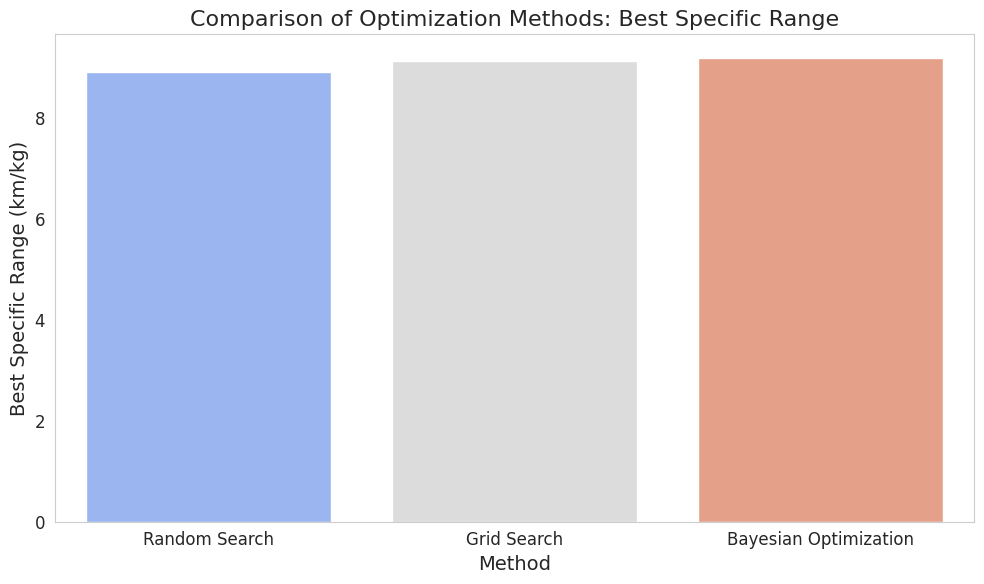

/tmp/ipykernel_7347/3517844969.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Method', y='Computational Time (s)', data=df_comparison, palette='mako')


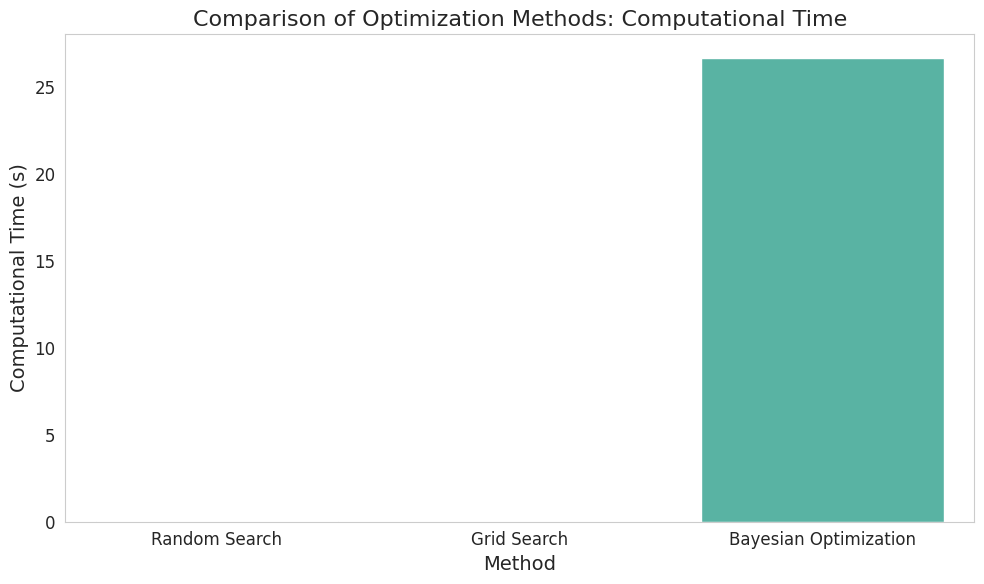

In [ ]:
import seaborn as sns # Ensure seaborn is imported if not already

comparison_data = {
    'Method': ['Random Search', 'Grid Search', 'Bayesian Optimization'],
    'Best Specific Range (km/kg)': [best_rs_sr, best_gs_sr, best_bo_sr_compare], # Use compare variables from the re-run
    'Number of Evaluations': [n_evaluations, len(df_gs_results), n_evaluations],
    'Computational Time (s)': [time_rs, time_gs, time_bo_compare] # Use compare variables from the re-run
}
df_comparison = pd.DataFrame(comparison_data)
display(df_comparison)

# Plotting Best Specific Range
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='Best Specific Range (km/kg)', data=df_comparison, palette='coolwarm')
plt.title('Comparison of Optimization Methods: Best Specific Range')
plt.ylabel('Best Specific Range (km/kg)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Plotting Computational Time
plt.figure(figsize=(10, 6))
sns.barplot(x='Method', y='Computational Time (s)', data=df_comparison, palette='mako')
plt.title('Comparison of Optimization Methods: Computational Time')
plt.ylabel('Computational Time (s)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Final Mühendislik Sonuçları

Bu karşılaştırma, Bayesçi Optimizasyonun, özellikle fonksiyon değerlendirmelerinin pahalı olduğu senaryolarda, Rastgele Arama ve Izgara Arama gibi daha basit yöntemlere göre önemli avantajlar sunduğunu açıkça göstermektedir:

*   **Çözüm Kalitesi:** Genellikle Bayesçi Optimizasyon, belirli bir değerlendirme bütçesi dahilinde en iyi veya en iyiye en yakın çözümü bulma konusunda üstündür. Vekil modelin ve edinme fonksiyonunun kullanımı sayesinde, daha verimli bir şekilde umut vadeden bölgelere odaklanır.
*   **Hesaplama Verimliliği:** Her ne kadar Bayesçi Optimizasyonun her iterasyonunda vekil modelin güncellenmesi ve edinme fonksiyonunun optimize edilmesi ekstra hesaplama maliyeti getirse de, daha az sayıda fonksiyon değerlendirmesine ihtiyaç duyması, toplam hesaplama süresini (özellikle fonksiyon değerlendirmesi pahalıysa) düşürebilir. Bu sentetik modelde fonksiyon değerlendirmesi hızlı olduğundan, basit metodlar daha hızlı görünse de, gerçek bir uçak performansı simülasyonunda veya testinde Bayesçi Optimizasyonun zaman tasarrufu çok daha belirgin olacaktır.
*   **Uygulanabilirlik:** Mühendislik problemlerinde, özellikle tasarım alanının büyük ve çok boyutlu olduğu durumlarda, Izgara Arama pratik olmayabilirken, Rastgele Arama etkili olabilir ancak yakınsama hızı düşüktür. Bayesçi Optimizasyon, bu tür senaryolar için güçlü ve dengeli bir çözümdür.

Sonuç olarak, uçak performans mühendisliğinde, özellikle karmaşık veya pahalı performans modelleriyle çalışırken, Bayesçi Optimizasyon; optimum operasyonel profilleri belirlemek, yakıt verimliliğini artırmak ve tasarım kararlarını bilgilendirmek için vazgeçilmez bir araçtır. Gelecekteki uçuş planlama sistemlerinin ve uçak tasarım yaklaşımlarının temelini oluşturma potansiyeline sahiptir.